In [1]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu
CUDA available: False


## What is happening in the next code?
This code sets the project folder on your D: drive and points to the `data/manifests` folder. It also sets the device to CPU, so the model will train on the processor, not a GPU.
It loads the saved train and validation CSV files, and gets the sorted list of class names from the training labels.
Then it gives each class a number (`class_to_idx`) and prints the device, the image counts, and this class-to-number mapping.

In [2]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(
    r"D:\Maktab_Sharif_Projects\traffic-vehicle-classification"
)
MANIFEST_DIR = PROJECT_ROOT / "data" / "manifests"
DEVICE = torch.device("cpu")

train_df = pd.read_csv(MANIFEST_DIR / "train.csv")
val_df = pd.read_csv(MANIFEST_DIR / "validation.csv")

classes = sorted(train_df["label"].unique())
class_to_idx = {label: index for index, label in enumerate(classes)}

print("Device:", DEVICE)
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Class mapping:", class_to_idx)

Device: cpu
Training images: 2458
Validation images: 527
Class mapping: {'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'kamyunet': 3, 'minibus': 4, 'savari': 5, 'taxi': 6, 'vanet': 7}


## What is happening in the next code?
This code defines a custom `ResizeWithPadding` step. It fixes the image rotation, shrinks the image to fit inside 224x224 without stretching it, and puts it in the center of a gray square canvas.
The training transform first fixes the rotation, then applies a random horizontal flip and small color changes, then resizes with padding, turns the image into a tensor, and normalizes it.
The validation transform only resizes with padding, converts to a tensor, and normalizes, so it has no randomness. This way the image proportions are kept, and the gray padding is close to the average color that ImageNet models expect.

In [4]:
from PIL import Image, ImageOps
from torchvision import transforms

IMAGE_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]


class ResizeWithPadding:
    def __init__(self, size=224):
        self.size = size

    def __call__(self, image):
        image = ImageOps.exif_transpose(image).convert("RGB")

        image = ImageOps.contain(
            image,
            (self.size, self.size),
            method=Image.Resampling.BILINEAR,
        )

        canvas = Image.new(
            "RGB",
            (self.size, self.size),
            color=(124, 116, 104),
        )
        position = (
            (self.size - image.width) // 2,
            (self.size - image.height) // 2,
        )
        canvas.paste(image, position)
        return canvas


train_transform = transforms.Compose([
    # Correct image orientation before augmentation
    transforms.Lambda(
        lambda image: ImageOps.exif_transpose(image).convert("RGB")
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
    ),
    ResizeWithPadding(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    ResizeWithPadding(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

print("Transformations ready: 224 × 224, with proportions preserved.")

Transformations ready: 224 × 224, with proportions preserved.


In [ ]:
from torch.utils.data import Dataset, DataLoader


class VehicleDataset(Dataset):
    def __init__(self, dataframe, transform, class_to_idx):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["path"]) as image:
            image = self.transform(image)

        label = self.class_to_idx[row["label"]]
        return image, label


train_dataset = VehicleDataset(train_df, train_transform, class_to_idx)
val_dataset = VehicleDataset(val_df, val_transform, class_to_idx)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image values finite:", torch.isfinite(images).all().item())

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Image values finite: True


## What is happening in the next code?
This code undoes the normalization (multiplies by std and adds mean) and clamps the values to 0-1, so the images look like normal pictures again.
It creates a grid with 2 rows and 4 columns and shows the first 8 images from the batch we loaded before.
Each image has its class name as the title and no axes, so you can quickly check that the images, padding, and labels look correct.

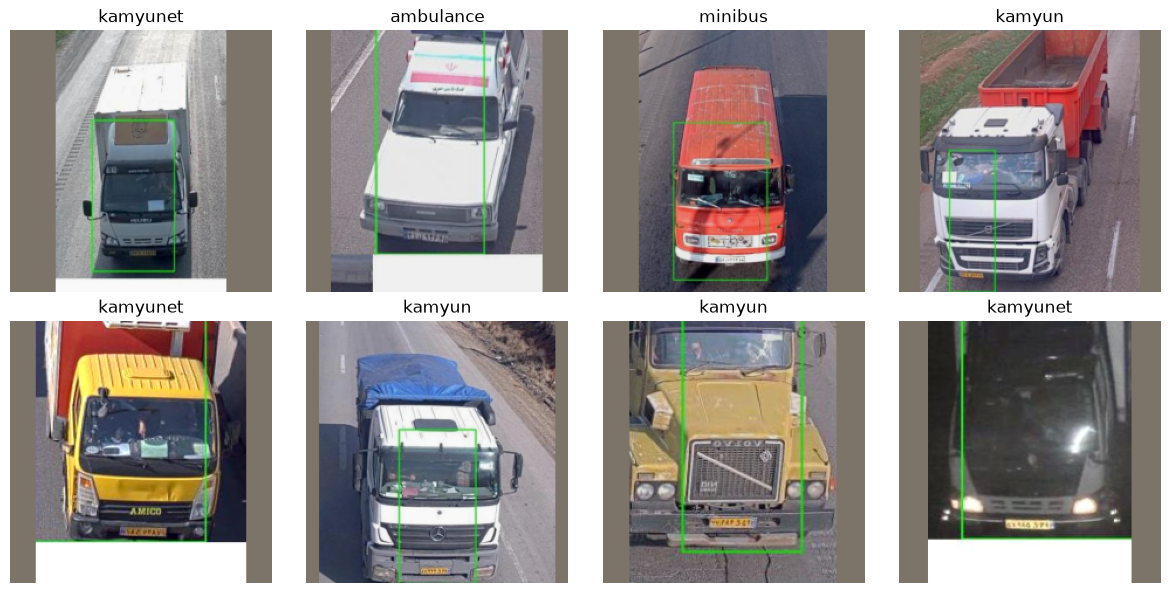

In [6]:
import matplotlib.pyplot as plt

mean = torch.tensor(MEAN).view(3, 1, 1)
std = torch.tensor(STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for index, ax in enumerate(axes.flat):
    image = (images[index].cpu() * std + mean).clamp(0, 1)
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.set_title(classes[labels[index].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

## What is happening in the next code?
This code sets the random seed (42) for Python, NumPy, and PyTorch, so the results are the same every time you run it.
It loads a ResNet18 model that was already trained on ImageNet and freezes all its layers, so they will not change during training.
Then it replaces the last layer with a new one that has one output for each class (8 classes), moves the model to the CPU, and prints the number of parameters that will be trained (only the new layer).

In [7]:
import random
import numpy as np
from torch import nn
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

model = resnet18(weights=ResNet18_Weights.DEFAULT)

for parameter in model.parameters():
    parameter.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(DEVICE)

print("Model: ResNet18")
print("Output classes:", model.fc.out_features)
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad),
)

Model: ResNet18
Output classes: 8
Trainable parameters: 4104


## What is happening in the next code?
This code sets the training settings: 20 epochs, a learning rate of 0.001, and a small weight decay (0.0001) to reduce overfitting.
It uses CrossEntropyLoss to measure the error, and the AdamW optimizer, which updates only the new final layer (`model.fc`) because the other layers are frozen.
A scheduler cuts the learning rate in half if the validation loss does not improve for 2 epochs, and a `checkpoints` folder is created to save the model later.
Finally, it prints the main settings.

In [8]:
EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

CHECKPOINT_DIR = PROJECT_ROOT / "outputs" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Optimizer: AdamW")
print("Loss: CrossEntropyLoss")

Epochs: 20
Learning rate: 0.001
Weight decay: 0.0001
Optimizer: AdamW
Loss: CrossEntropyLoss


## What is happening in the next three codes?
This code defines `train_fc_model`, the training loop. The frozen ResNet18 layers stay in eval mode and only the final layer (`fc`) trains, one epoch at a time. Each epoch it measures loss and accuracy on the training data, then on the validation data.
After every epoch it lowers the learning rate if needed, saves the best model (highest validation accuracy) as a checkpoint, and writes the history to a CSV file.
It also defines `plot_training_results`, which draws three charts (loss, accuracy with the best point marked, and learning rate) and saves the figure as a PNG.
Finally, it runs the training for 20 epochs and plots the results.

In [9]:
import time

def train_fc_model(model, train_loader, val_loader):
    history = []
    best_accuracy = -1.0
    best_loss = float("inf")
    checkpoint_path = CHECKPOINT_DIR / "resnet18_fc_best.pt"

    for epoch in range(1, EPOCHS + 1):
        start = time.perf_counter()

        model.eval()
        model.fc.train()

        train_loss = 0.0
        train_correct = 0
        train_count = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * labels.size(0)
            train_correct += (logits.argmax(1) == labels).sum().item()
            train_count += labels.size(0)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_count = 0

        with torch.inference_mode():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                logits = model(images)
                loss = criterion(logits, labels)

                val_loss += loss.item() * labels.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_count += labels.size(0)

        train_loss /= train_count
        val_loss /= val_count
        train_accuracy = train_correct / train_count
        val_accuracy = val_correct / val_count
        learning_rate = optimizer.param_groups[0]["lr"]

        scheduler.step(val_loss)

        if (
            val_accuracy > best_accuracy
            or (val_accuracy == best_accuracy and val_loss < best_loss)
        ):
            best_accuracy = val_accuracy
            best_loss = val_loss
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "class_to_idx": class_to_idx,
                "val_accuracy": val_accuracy,
                "val_loss": val_loss,
                "config": {
                    "architecture": "resnet18",
                    "mode": "fc",
                    "epochs": EPOCHS,
                    "initial_lr": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "batch_size": BATCH_SIZE,
                    "seed": SEED,
                    "image_size": IMAGE_SIZE,
                    "mean": MEAN,
                    "std": STD,
                    "resize": "aspect_ratio_with_padding",
                },
            }, checkpoint_path)

        seconds = time.perf_counter() - start
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "learning_rate": learning_rate,
            "seconds": seconds,
        })

        pd.DataFrame(history).to_csv(
            CHECKPOINT_DIR.parent / "resnet18_fc_history.csv",
            index=False,
        )

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train loss {train_loss:.4f}, acc {train_accuracy:.2%} | "
            f"Val loss {val_loss:.4f}, acc {val_accuracy:.2%} | "
            f"LR {learning_rate:.6f} | {seconds:.0f}s",
            flush=True,
        )

    print(f"\nBest validation accuracy: {best_accuracy:.2%}")
    print("Checkpoint:", checkpoint_path)
    return pd.DataFrame(history)

print("Training loop ready.")

Training loop ready.


In [10]:
import matplotlib.pyplot as plt

def plot_training_results(history):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(history["epoch"], history["train_loss"], label="Train")
    axes[0].plot(history["epoch"], history["val_loss"], label="Validation")
    axes[0].set_title("Loss")
    axes[0].set_ylabel("Cross-entropy loss")

    axes[1].plot(
        history["epoch"], history["train_accuracy"] * 100, label="Train"
    )
    axes[1].plot(
        history["epoch"], history["val_accuracy"] * 100, label="Validation"
    )
    axes[1].set_title("Accuracy")
    axes[1].set_ylabel("Accuracy (%)")

    best = history.loc[
        history.sort_values(
            ["val_accuracy", "val_loss"],
            ascending=[False, True],
        ).index[0]
    ]
    axes[1].scatter(
        best["epoch"],
        best["val_accuracy"] * 100,
        color="red",
        zorder=5,
        label=f'Best validation: {best["val_accuracy"]:.2%}',
    )

    axes[2].step(
        history["epoch"], history["learning_rate"], where="post"
    )
    axes[2].set_title("Learning rate used per epoch")
    axes[2].set_ylabel("Learning rate")
    axes[2].set_yscale("log")

    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.25)

    axes[0].legend()
    axes[1].legend()
    fig.suptitle("ResNet18 — FC training")
    fig.tight_layout()

    figure_dir = PROJECT_ROOT / "outputs" / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    figure_path = figure_dir / "resnet18_fc_training.png"
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Figure saved:", figure_path)

print("Plotting function ready.")

Plotting function ready.


Epoch 01/20 | Train loss 1.2654, acc 62.04% | Val loss 0.7832, acc 80.83% | LR 0.001000 | 226s
Epoch 02/20 | Train loss 0.6362, acc 84.17% | Val loss 0.5248, acc 85.58% | LR 0.001000 | 232s
Epoch 03/20 | Train loss 0.4832, acc 87.35% | Val loss 0.4305, acc 88.80% | LR 0.001000 | 231s
Epoch 04/20 | Train loss 0.4045, acc 89.54% | Val loss 0.3825, acc 88.61% | LR 0.001000 | 230s
Epoch 05/20 | Train loss 0.3635, acc 90.48% | Val loss 0.3484, acc 89.18% | LR 0.001000 | 230s
Epoch 06/20 | Train loss 0.3268, acc 91.38% | Val loss 0.3187, acc 89.37% | LR 0.001000 | 231s
Epoch 07/20 | Train loss 0.3062, acc 91.38% | Val loss 0.2970, acc 91.27% | LR 0.001000 | 230s
Epoch 08/20 | Train loss 0.2805, acc 92.07% | Val loss 0.2992, acc 90.70% | LR 0.001000 | 230s
Epoch 09/20 | Train loss 0.2599, acc 93.37% | Val loss 0.2688, acc 90.70% | LR 0.001000 | 233s
Epoch 10/20 | Train loss 0.2397, acc 93.57% | Val loss 0.2643, acc 92.03% | LR 0.001000 | 230s
Epoch 11/20 | Train loss 0.2351, acc 93.86% | Val 

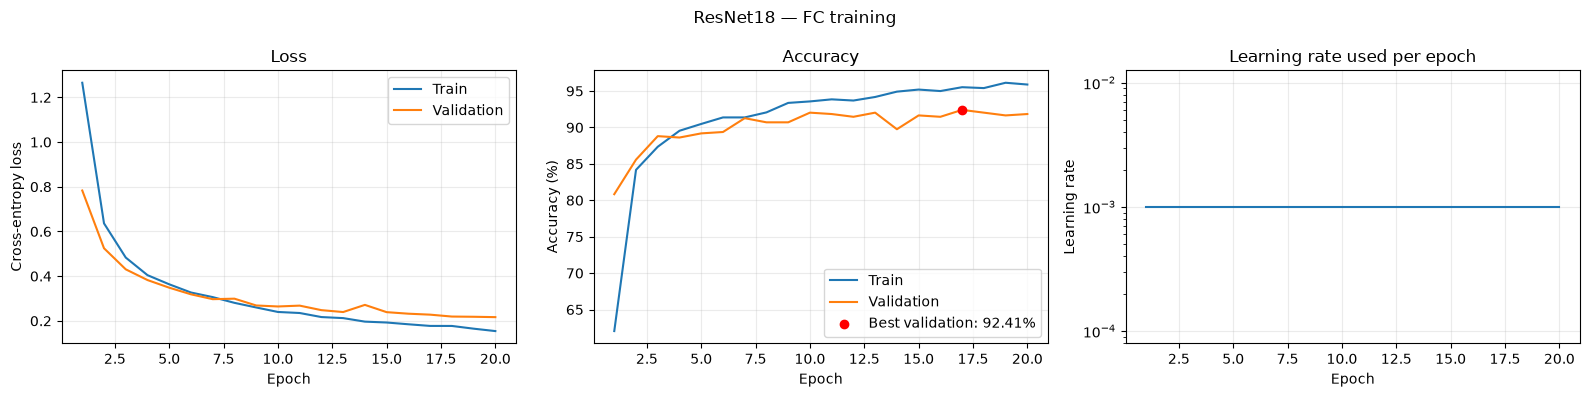

Figure saved: D:\Maktab_Sharif_Projects\traffic-vehicle-classification\outputs\figures\resnet18_fc_training.png


In [ ]:
history = train_fc_model(model, train_loader, val_loader)
plot_training_results(history)